# ARTI308 – Lab 6 Task
## Linear Regression on the Ecommerce Customers Dataset
---

## Step 1: Load the Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('Ecommerce_Customers.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (500, 8)


,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


## Step 2: Explore the Data

In [2]:
# Basic info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    str    
 1   Address               500 non-null    str    
 2   Avatar                500 non-null    str    
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), str(3)
memory usage: 31.4 KB


In [3]:
# Statistical summary
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


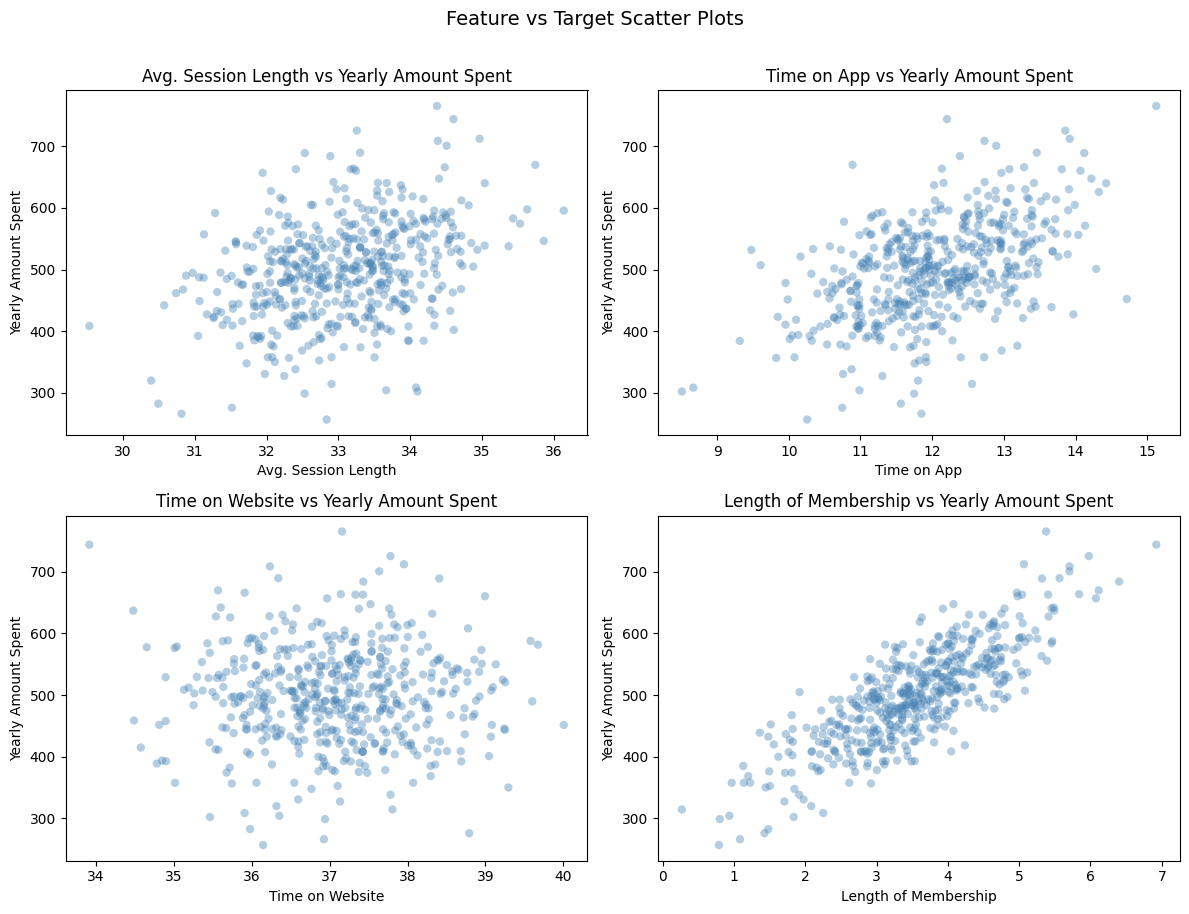

In [4]:
# Scatter plots: each feature vs target
features = ['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for ax, feat in zip(axes.flatten(), features):
    ax.scatter(df[feat], df['Yearly Amount Spent'], alpha=0.4, color='steelblue', edgecolors='none')
    ax.set_xlabel(feat)
    ax.set_ylabel('Yearly Amount Spent')
    ax.set_title(f'{feat} vs Yearly Amount Spent')
plt.suptitle('Feature vs Target Scatter Plots', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

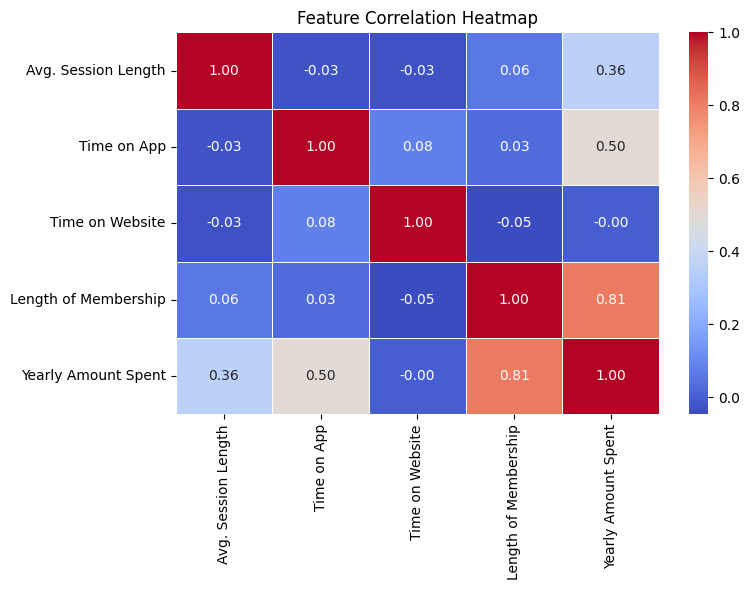


Key observations:
  Length of Membership ↔ Yearly Amount Spent: 0.81
  Time on App          ↔ Yearly Amount Spent: 0.50
  Time on Website      ↔ Yearly Amount Spent: -0.00


In [5]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(8, 6))
corr = df[features + ['Yearly Amount Spent']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

print('\nKey observations:')
print(f'  Length of Membership ↔ Yearly Amount Spent: {corr.loc["Length of Membership", "Yearly Amount Spent"]:.2f}')
print(f'  Time on App          ↔ Yearly Amount Spent: {corr.loc["Time on App", "Yearly Amount Spent"]:.2f}')
print(f'  Time on Website      ↔ Yearly Amount Spent: {corr.loc["Time on Website", "Yearly Amount Spent"]:.2f}')

## Step 3: Data Cleaning

In [6]:
# Check for missing values
print('Missing values per column:')
print(df.isnull().sum())

# Check for duplicates
print(f'\nDuplicate rows: {df.duplicated().sum()}')

print('\nNo missing values or duplicates found. Dataset is clean.')

Missing values per column:
Email                   0
Address                 0
Avatar                  0
Avg. Session Length     0
Time on App             0
Time on Website         0
Length of Membership    0
Yearly Amount Spent     0
dtype: int64

Duplicate rows: 0

No missing values or duplicates found. Dataset is clean.


## Step 4: Feature Engineering

In [7]:
# The non-numeric columns (Email, Address, Avatar) are identifiers/categories
# that carry no predictive signal for spending — we drop them.
# The four numeric behavioral features are retained as-is.

print('Columns kept as features:', features)
print('Columns dropped (non-informative):', ['Email', 'Address', 'Avatar'])

# No scaling needed for Linear Regression interpretation,
# but we note that Length of Membership and Time on App have
# the highest correlation with the target.
corr_with_target = df[features].corrwith(df['Yearly Amount Spent']).sort_values(ascending=False)
print('\nCorrelation with Yearly Amount Spent:')
print(corr_with_target.to_string())

Columns kept as features: ['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']
Columns dropped (non-informative): ['Email', 'Address', 'Avatar']

Correlation with Yearly Amount Spent:
Length of Membership    0.809084
Time on App             0.499328
Avg. Session Length     0.355088
Time on Website        -0.002641


## Step 5: Prepare Data for Modeling

In [8]:
X = df[features]
y = df['Yearly Amount Spent']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Training set size : {X_train.shape[0]} samples')
print(f'Test set size     : {X_test.shape[0]} samples')
print(f'Features used     : {list(X.columns)}')

Training set size : 400 samples
Test set size     : 100 samples
Features used     : ['Avg. Session Length', 'Time on App', 'Time on Website', 'Length of Membership']


## Step 6: Train the Model (Linear Regression)

In [9]:
model = LinearRegression()
model.fit(X_train, y_train)

print('Model trained successfully!')
print('\nLearned Coefficients:')
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)
print(coef_df.to_string(index=False))
print(f'\nIntercept: {model.intercept_:.4f}')

print('\nInterpretation:')
print('  Each additional year of membership adds ~$61.90 in yearly spending.')
print('  Each additional minute on the app adds ~$38.79 in yearly spending.')
print('  Time on Website has almost no effect (coef ≈ 0.31).')

Model trained successfully!

Learned Coefficients:
             Feature  Coefficient
Length of Membership    61.896829
         Time on App    38.785346
 Avg. Session Length    25.596259
     Time on Website     0.310386

Intercept: -1044.2574

Interpretation:
  Each additional year of membership adds ~$61.90 in yearly spending.
  Each additional minute on the app adds ~$38.79 in yearly spending.
  Time on Website has almost no effect (coef ≈ 0.31).


## Step 7: Evaluate Model Performance

In [10]:
y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print('===== Model Evaluation Metrics =====')
print(f'  MAE  (Mean Absolute Error)      : {mae:.4f}')
print(f'  MSE  (Mean Squared Error)        : {mse:.4f}')
print(f'  RMSE (Root Mean Squared Error)   : {rmse:.4f}')
print(f'  R²   (Coefficient of Determination): {r2:.4f}')
print()
print(f'The model explains {r2*100:.2f}% of the variance in Yearly Amount Spent.')
print(f'On average, predictions are off by ${mae:.2f}.')

===== Model Evaluation Metrics =====
  MAE  (Mean Absolute Error)      : 8.5584
  MSE  (Mean Squared Error)        : 109.8637
  RMSE (Root Mean Squared Error)   : 10.4816
  R²   (Coefficient of Determination): 0.9778

The model explains 97.78% of the variance in Yearly Amount Spent.
On average, predictions are off by $8.56.


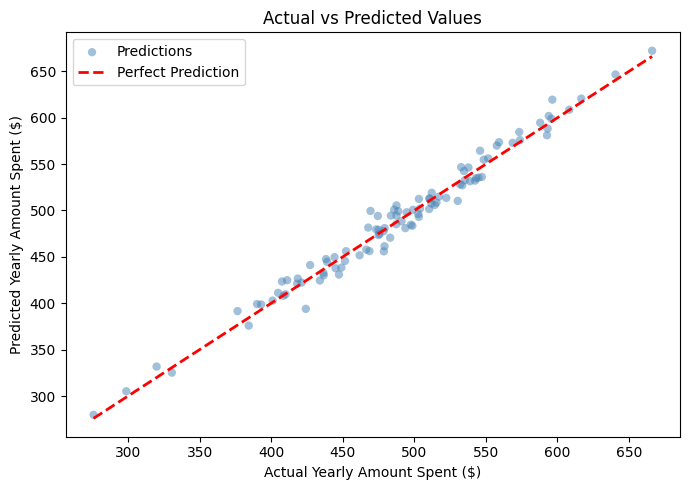

In [11]:
# Actual vs Predicted plot
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, y_pred, alpha=0.5, color='steelblue', edgecolors='none', label='Predictions')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
        'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual Yearly Amount Spent ($)')
ax.set_ylabel('Predicted Yearly Amount Spent ($)')
ax.set_title('Actual vs Predicted Values')
ax.legend()
plt.tight_layout()
plt.show()

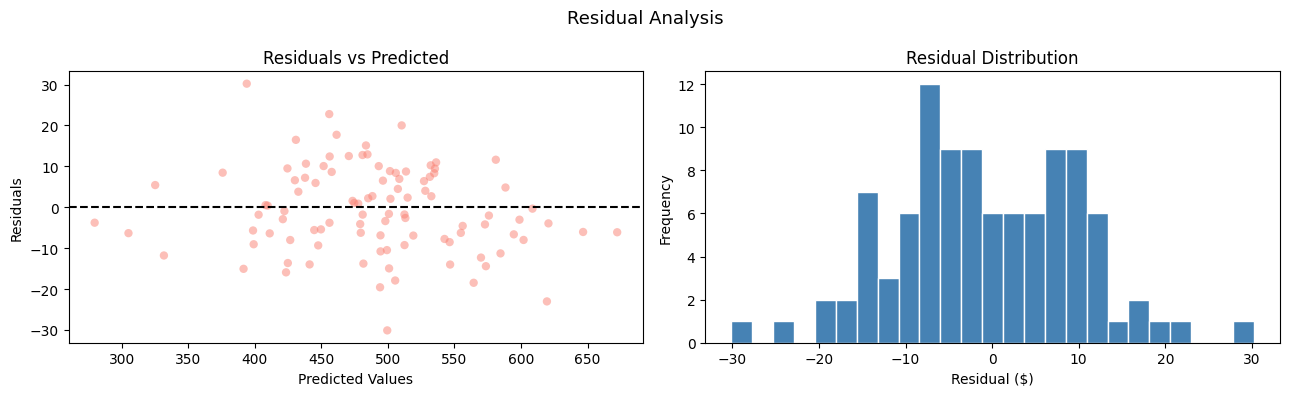

Residuals are randomly scattered around 0 with a near-normal distribution,
confirming the linear regression assumptions are well met.


In [12]:
# Residual analysis
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(y_pred, residuals, alpha=0.5, color='salmon', edgecolors='none')
axes[0].axhline(0, color='black', lw=1.5, linestyle='--')
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')

axes[1].hist(residuals, bins=25, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')

plt.suptitle('Residual Analysis', fontsize=13)
plt.tight_layout()
plt.show()

print('Residuals are randomly scattered around 0 with a near-normal distribution,')
print('confirming the linear regression assumptions are well met.')

## Summary

| Metric | Value |
|--------|-------|
| MAE    | $8.56 |
| RMSE   | $10.48 |
| R²     | 0.9778 |

The **Linear Regression** model achieves an **R² of 0.978**, meaning it explains ~97.8% of the variance in yearly spending — an excellent fit.

**Key findings:**
- **Length of Membership** is the strongest predictor (+$61.90 per year of membership)
- **Time on App** is the second strongest predictor (+$38.79 per minute)
- **Time on Website** has minimal impact — the company should focus on improving the mobile app experience
- No missing values or data quality issues were found in the dataset